In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler
import numpy as np
import matplotlib.pyplot as plt

## GROUP 13 Lab 08

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196


# PROBLEM 3
## Damped Harmonic Oscillator — Euler-Cromer Simulation

The equation of motion of the damped oscillator is:

$$
\ddot{x} + 2b\dot{x} + \omega_0^2\,x = 0
$$

with initial conditions $x(0) = 0$, $\dot{x}(0) = 1$, and $\omega_0 = 1$.

### Analytical Solution

Setting $v = \dot{x}$, the system becomes:

$$
\dot{v} = -2b\,v - \omega_0^2\,x, \qquad \dot{x} = v
$$

The characteristic equation is $r^2 + 2b\,r + \omega_0^2 = 0$, with roots:

$$
r = -b \pm \sqrt{b^2 - \omega_0^2}
$$

The behaviour depends on the discriminant $\Delta = b^2 - \omega_0^2$:

---

**Case 1 — Underdamped** ($b < \omega_0$, $\;\Delta < 0$)

Define the damped frequency $\omega_d = \sqrt{\omega_0^2 - b^2}$. Applying $x(0)=0$, $v(0)=1$:

$$
\boxed{x(t) = \frac{e^{-bt}}{\omega_d}\sin(\omega_d\,t)}
$$

The system oscillates at reduced frequency $\omega_d < \omega_0$ with an exponentially decaying amplitude envelope $e^{-bt}$.

---

**Case 2 — Critically Damped** ($b = \omega_0$, $\;\Delta = 0$)

Repeated root $r = -b$. Applying initial conditions:

$$
\boxed{x(t) = t\,e^{-bt}}
$$

No oscillation. The system returns to equilibrium in the **shortest time** without overshooting. Peak displacement occurs at $t^* = 1/b$.

---

**Case 3 — Overdamped** ($b > \omega_0$, $\;\Delta > 0$)

Define $\gamma = \sqrt{b^2 - \omega_0^2}$. Applying initial conditions:

$$
\boxed{x(t) = \frac{e^{-bt}}{\gamma}\sinh(\gamma\,t)}
$$

No oscillation. The system decays more slowly than the critical case — large damping resists both the driving and the restoring force.

---

### Euler-Cromer Discretisation

Using the symplectic Euler-Cromer algorithm (velocity updated first, then position):

$$
v_{n+1} = v_n + \Delta t\left(-2b\,v_n - \omega_0^2\,x_n\right)
$$
$$
x_{n+1} = x_n + \Delta t\,v_{n+1}
$$

Parameters: $\omega_0 = 1$, $\Delta t = 0.01$, $t_{\max} = 20$ s.


## Setup: Parameters and Damping Cases


In [ ]:
# Parameters
w0    = 1       # natural frequency (rad/s)
t_max = 20      # total time (≥ 3 full cycles for underdamped case)
dt    = 0.01    # time step

# Initial conditions
x0 = 0.0
v0 = 1.0

# Damping cases:  b < w0 → underdamped | b = w0 → critical | b > w0 → overdamped
b_values = {
    'Underdamped  (b = 0.2)' : 0.2,
    'Critical     (b = 1.0)' : 1.0,
    'Overdamped   (b = 2.0)' : 2.0,
}


## Simulation: $t$ vs $x(t)$ for Three Damping Regimes

We run the Euler-Cromer loop for each damping value and overlay all three solutions on a single plot.


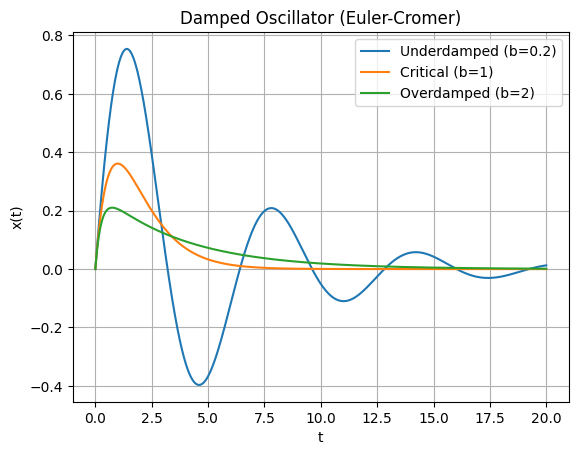

In [ ]:
colors = ['steelblue', 'crimson', 'seagreen']

plt.figure(figsize=(10, 5))

for (label, b), col in zip(b_values.items(), colors):
    N = int(t_max / dt)
    t = np.linspace(0, t_max, N)

    x = np.zeros(N)
    v = np.zeros(N)
    x[0], v[0] = x0, v0

    # Euler-Cromer: update velocity first, then position with new velocity
    for n in range(N - 1):
        v[n+1] = v[n] + dt * (-2*b*v[n] - w0**2 * x[n])
        x[n+1] = x[n] + dt * v[n+1]

    plt.plot(t, x, color=col, linewidth=1.0, label=label)

plt.axhline(0, color='black', linewidth=0.6, linestyle=':')
plt.title(r'Damped Oscillator: $\ddot{x} + 2b\dot{x} + \omega_0^2 x = 0$ — Euler-Cromer')
plt.xlabel('$t$')
plt.ylabel('$x(t)$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## Observations

### Underdamped ($b = 0.2 < \omega_0 = 1$)

The damped frequency is $\omega_d = \sqrt{1 - 0.04} \approx 0.98$ rad/s, giving period $T_d \approx 6.4$ s. The amplitude decays as $e^{-0.2t}$: after one period the envelope shrinks by $e^{-1.28} \approx 0.28$. Three complete cycles are clearly visible before the signal becomes negligible.

### Critically Damped ($b = 1.0 = \omega_0$)

Solution $x(t) = t\,e^{-t}$ rises from zero, peaks at $t^* = 1/b = 1$ s where $x_{\max} = e^{-1} \approx 0.368$, then decays monotonically. No oscillation; this is the fastest possible return to equilibrium.

### Overdamped ($b = 2.0 > \omega_0$)

With $\gamma = \sqrt{4-1} = \sqrt{3} \approx 1.73$, the slow-decay mode goes as $e^{-(b-\gamma)t} = e^{-0.27t}$ — far slower than critical damping. The peak amplitude is lower than the critical case because the large damping strongly opposes the initial velocity. No oscillation.

### Comparison Table

| Regime | $b$ | Condition | Oscillates? | Return to equilibrium |
|--------|-----|-----------|-------------|----------------------|
| Underdamped | 0.2 | $b < \omega_0$ | Yes | Oscillatory decay |
| Critical | 1.0 | $b = \omega_0$ | No | Fastest monotonic |
| Overdamped | 2.0 | $b > \omega_0$ | No | Slowest monotonic |


## Conclusion

We numerically solved $\ddot{x} + 2b\dot{x} + \omega_0^2 x = 0$ using the Euler-Cromer algorithm for $\omega_0 = 1$, $x(0) = 0$, $v(0) = 1$.

- **Underdamped** ($b = 0.2$): oscillation at $\omega_d \approx 0.98$ rad/s with exponentially decaying amplitude — $x(t) = \frac{e^{-bt}}{\omega_d}\sin(\omega_d t)$. At least three complete cycles are observed.

- **Critically damped** ($b = 1.0$): no oscillation; fastest return to equilibrium via $x(t) = t\,e^{-t}$.

- **Overdamped** ($b = 2.0$): no oscillation; slowest return via $x(t) = \frac{e^{-bt}}{\gamma}\sinh(\gamma t)$ with $\gamma = \sqrt{3}$.

The Euler-Cromer method reproduces all three regimes accurately. Its symplectic property ensures that the underdamped amplitude follows the correct $e^{-bt}$ envelope without the spurious energy growth that afflicts the standard Euler method.
